State shape: torch.Size([2198, 6])
EE positions shape: (2198, 3)
First few positions:
[[-0.00737661  0.40764968  0.15916603]
 [-0.02087432  0.42566031  0.17001808]
 [ 0.00396118  0.4249568   0.16849572]
 [ 0.0226807   0.43305053  0.17199296]
 [-0.00445047  0.43394291  0.17031084]]
Min/Max values: X(-0.491, 0.504), Y(0.392, 0.926), Z(0.006, 0.460)


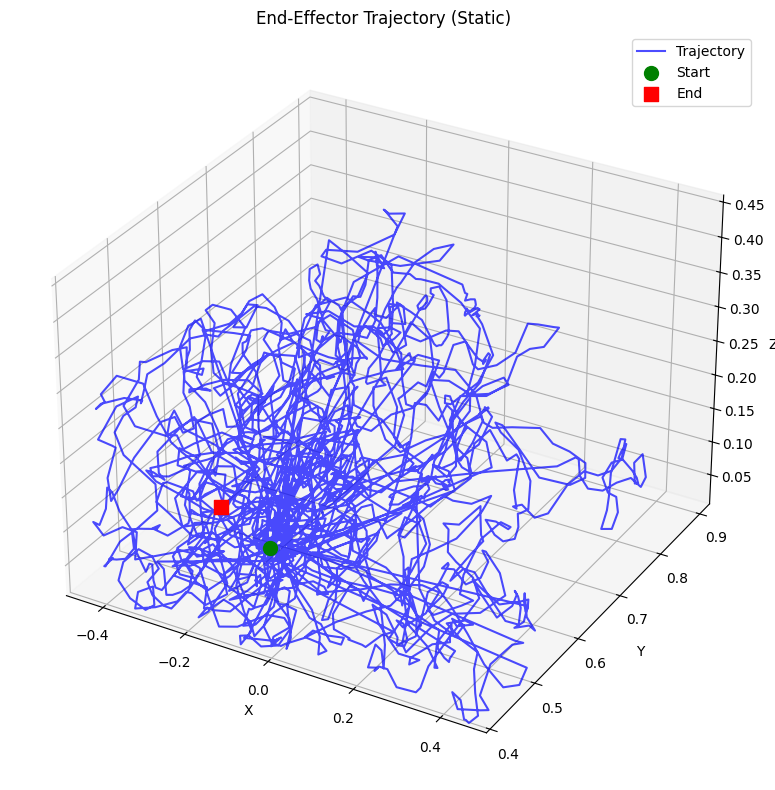

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
run_path = 'runs/coffee/2026-01-25_03-42-53'

# Load saved state
state = torch.load(PROJECT_ROOT / run_path / 'state.pt')
print(f"State shape: {state.shape}")

# Convert to numpy
ee_positions = state[:, 0:3]
if isinstance(ee_positions, torch.Tensor):
    ee_positions = ee_positions.cpu().numpy()

print(f"EE positions shape: {ee_positions.shape}")
print(f"First few positions:\n{ee_positions[:5]}")
print(f"Min/Max values: X({ee_positions[:, 0].min():.3f}, {ee_positions[:, 0].max():.3f}), "
      f"Y({ee_positions[:, 1].min():.3f}, {ee_positions[:, 1].max():.3f}), "
      f"Z({ee_positions[:, 2].min():.3f}, {ee_positions[:, 2].max():.3f})")

x, y, z = ee_positions[:, 0], ee_positions[:, 1], ee_positions[:, 2]

# Create static 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, 'b-', linewidth=1.5, alpha=0.7, label='Trajectory')
ax.scatter(x[0], y[0], z[0], color='green', s=100, label='Start', marker='o')
ax.scatter(x[-1], y[-1], z[-1], color='red', s=100, label='End', marker='s')

ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_zlim(z.min(), z.max())

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('End-Effector Trajectory (Static)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()